In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

In [59]:
data = pd.read_csv("GOOGL.csv", parse_dates=['Date'])
# Ensure data is sorted by date
data = data.sort_values('Date')

In [60]:
# Using multiple features helps the RNN learn patterns better than just 'Close'
features = ['Open', 'High', 'Low', 'Close', 'Volume']
data_full = data[features].values

In [62]:
print(data_full)

[[5.00500490e+01 5.20820810e+01 4.80280270e+01 5.02202190e+01
  4.46590960e+07]
 [5.05555570e+01 5.45945970e+01 5.03003010e+01 5.42092090e+01
  2.28343430e+07]
 [5.54304310e+01 5.67967990e+01 5.45795780e+01 5.47547530e+01
  1.82561260e+07]
 ...
 [2.72203003e+03 2.82100000e+03 2.72203003e+03 2.79736011e+03
  1.77480000e+06]
 [2.77405005e+03 2.79177002e+03 2.75669995e+03 2.76551001e+03
  1.25770000e+06]
 [2.78400000e+03 2.83237988e+03 2.75501001e+03 2.83143994e+03
  1.31790000e+06]]


In [63]:
# Split index for training/testing (e.g., 80% training)
train_size = int(len(data_full) * 0.8)
train_data = data_full[:train_size]
test_data = data_full[train_size:]

In [64]:
# Scale features
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
# Use the same scaler for test data to avoid leakage
test_scaled = scaler.transform(test_data)

In [65]:
# =====================================================
# 2. Create Sequences (Windowing)
# =====================================================
def create_sequences(data, window_size=60):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        # We want to predict the 'Close' price (index 3 in our features list)
        y.append(data[i, 3])
    return np.array(X), np.array(y)

window_size = 60
X_train, y_train = create_sequences(train_scaled, window_size)

In [66]:
# For test sequences, we need the last window_size days from training
last_train_days = train_scaled[-window_size:]
full_test_input = np.vstack((last_train_days, test_scaled))
X_test, y_test = create_sequences(full_test_input, window_size)

In [67]:
model = Sequential([
    LSTM(units=60, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(units=60, return_sequences=False),
    Dropout(0.2),
    Dense(units=25),
    Dense(units=1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [68]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1)

Epoch 1/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 13s 75ms/step - loss: 0.0082
Epoch 2/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - loss: 0.0014
Epoch 3/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - loss: 0.0012
Epoch 4/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - loss: 9.0963e-04
Epoch 5/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step - loss: 9.1306e-04
Epoch 6/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - loss: 8.2750e-04
Epoch 7/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - loss: 6.9732e-04
Epoch 8/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - loss: 7.3529e-04
Epoch 9/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - loss: 6.4647e-04
Epoch 10/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - loss: 6.1247e-04
Epoch 11/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - loss: 6.5521e-04
Epoch 12/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - loss: 5.6830e-04
Epoch 13/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - loss: 5.7798e-04
Epoch 14/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - loss: 6.173

In [69]:
predictions = model.predict(X_test)

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


In [70]:
prediction_copies = np.repeat(predictions, len(features), axis=-1)
y_pred_final = scaler.inverse_transform(prediction_copies)[:, 3]

In [71]:
# Inverse scale the actual values (y_test) for comparison
test_copies = np.repeat(y_test.reshape(-1, 1), len(features), axis=-1)
y_test_final = scaler.inverse_transform(test_copies)[:, 3]

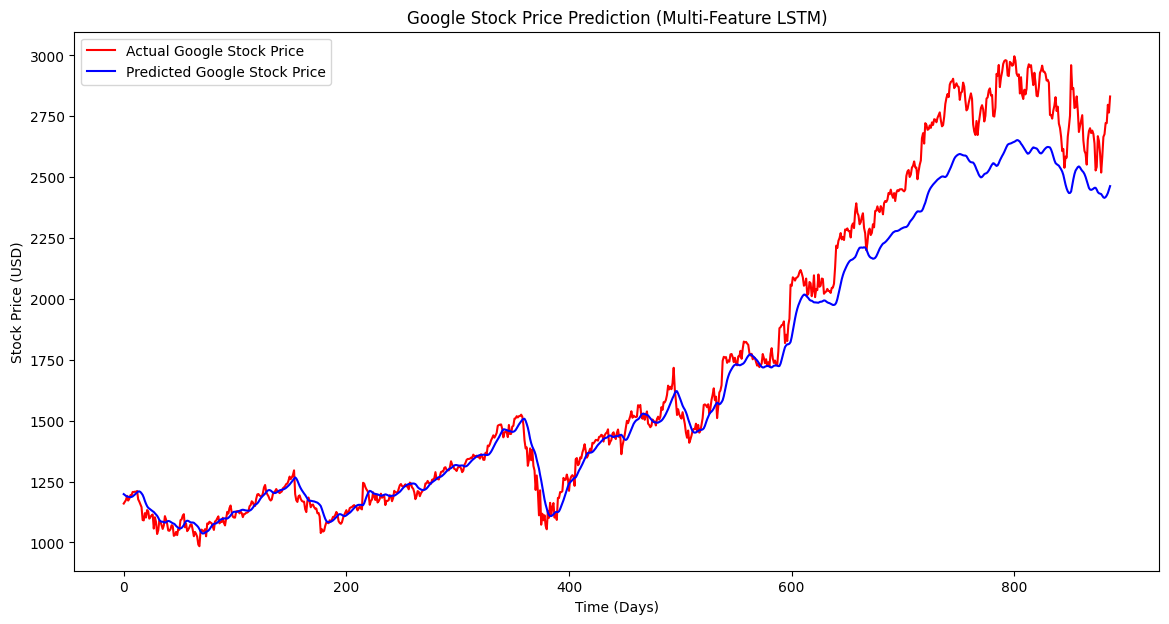

In [72]:
plt.figure(figsize=(14, 7))
plt.plot(y_test_final, color='red', label='Actual Google Stock Price')
plt.plot(y_pred_final, color='blue', label='Predicted Google Stock Price')
plt.title('Google Stock Price Prediction (Multi-Feature LSTM)')
plt.xlabel('Time (Days)')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.show()